In [4]:
from langgraph.graph import StateGraph, START, MessagesState
from langchain_google_genai import ChatGoogleGenerativeAI

from dotenv import load_dotenv

In [5]:
load_dotenv()

True

In [6]:
model =  ChatGoogleGenerativeAI(
    model="gemini-2.5-flash"
)

In [7]:
def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

In [8]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

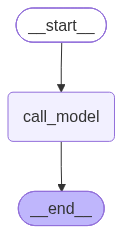

In [9]:
graph = builder.compile()
graph

In [11]:
graph.invoke({"messages": [{"role": "user", "content": "Hi! My name is Satyam."}]})

{'messages': [HumanMessage(content='Hi! My name is Satyam.', additional_kwargs={}, response_metadata={}, id='5eb66e00-47b2-4abd-acc5-2e8e5097ca4b'),
  AIMessage(content='Hi Satyam! Nice to meet you.\n\nHow can I help you today?', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0e7d7-6314-7551-84d3-6badb0363294-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9, 'output_tokens': 245, 'total_tokens': 254, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 228}})]}

In [12]:
graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]})

{'messages': [HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='5b111bbd-ebd5-4c2e-8276-dd841a92fbd9'),
  AIMessage(content="As an AI, I don't have access to personal information about you, including your name. I don't retain details from our conversations.\n\nIf you'd like to tell me your name, I'll be happy to refer to you by it during our current chat!", additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0e7d7-7aff-7720-9dd9-7bc4378f9676-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 6, 'output_tokens': 483, 'total_tokens': 489, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 425}})]}

In [ ]:
def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

In [ ]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

In [ ]:
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

In [ ]:
config = {"configurable": {"thread_id": "thread-1"}}
config2 = {"configurable": {"thread_id": "thread-2"}}

In [ ]:
graph.invoke({"messages": [{"role": "user", "content": "Hi! My name is Rocky"}]}, config)

In [ ]:
graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]}, config2)

In [ ]:
snap = graph.get_state(config)
vals = snap.values
for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content)